> **AI-generated.** An AI assistant drafted this page, and no maintainer has reviewed it yet. Please report errors on the issue tracker.

# Checking results

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/TARPS-group/prob-pipe/blob/dev/overhaul/docs/user_guide/06_checking_results.ipynb)

A posterior from an inference method is an approximation, and the model behind it is an assumption.
MCMC diagnostics check a sampler's draws, and predictive checks and leave-one-out cross-validation check models against the data.
Interval coverage and simulation-based calibration test whether a posterior's intervals contain the true parameters as often as they claim.
Read it after fitting a model, as [Conditioning and inference methods](05_conditioning_and_inference.ipynb) describes, and before relying on the fit.

In [1]:
# On Google Colab, install ProbPipe; elsewhere this cell does nothing.
try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    %pip install --quiet "probpipe-core @ git+https://github.com/TARPS-group/prob-pipe.git@dev/overhaul"

In [2]:
import warnings

import arviz as az
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from probpipe import (
    Normal,
    NumericArraySpec,
    condition_on,
    conditional_distribution,
    predictive_check,
    sample,
    workflow_run,
)
from probpipe.diagnostics import add_loo, add_mcmc_diagnostics, add_ppc
from probpipe.families import PoissonFamily, glm_likelihood
from probpipe.validation import interval_coverage, simulation_based_calibration

# TensorFlow Probability warns that JAX runs in 32-bit precision, which these models use.
warnings.filterwarnings("ignore", message=r"Explicitly requested dtype float64")

## MCMC diagnostics

The examples of this chapter use a Poisson regression of 20 counts `y` on a covariate `x`.
We simulate the counts from the model at known coefficients $\beta = (1.0, 0.8)$, so a later section can check the posterior's intervals against the truth.
The fit runs four short chains of 500 draws each.

In [3]:
x = jnp.linspace(-1.0, 1.0, 20)
X = jnp.stack([jnp.ones_like(x), x], axis=1)

prior = Normal("beta", jnp.zeros(2), jnp.full(2, 2.0))
likelihood = glm_likelihood("y", PoissonFamily(), X=X)
model = (likelihood * prior).with_label("with_slope")

true_beta = jnp.array([1.0, 0.8])
with workflow_run(seed=0):
    y = sample(condition_on(model, {"beta": true_beta})).raw().astype(jnp.int32)
print("simulated counts y:", y)

short_chains = {"num_warmup": 500, "num_results": 500}
with workflow_run(seed=1):
    posterior = condition_on.with_options(method_options=short_chains)(model, {"y": y})
print("posterior:", posterior)

simulated counts y: [3 0 1 2 5 1 1 3 3 4 4 4 3 7 4 6 3 7 9 5]


posterior: EmpiricalDistribution(
    'with_slope | y',
    atoms=NumericRecordBatch('posterior', levels={'chain': 4, 'draw': 500}, fields=('beta',)),
)


The posterior is an `EmpiricalDistribution` of four chains of correlated draws.
`add_mcmc_diagnostics` computes R-hat, the bulk and tail effective sample sizes, and the Monte Carlo standard error of the mean, and records them in the posterior's annotations.
`posterior.diagnostics` reads them, and `summary_table` prints one row per parameter:

In [4]:
add_mcmc_diagnostics(posterior)
print(posterior.diagnostics.summary_table())

Parameter     R-hat     ESS bulk    ESS tail    MCSE mean   
------------------------------------------------------------
beta[0]       1.0026    1051.0907   1023.2071   0.0039      
beta[1]       1.0001    1082.5417   1143.7015   0.0060      

✓  All available diagnostics passed.


R-hat compares the spread within each chain with the spread between chains, and a value below 1.01 indicates that the chains agree.
The effective sample size is the number of independent draws that the correlated draws are worth, for estimating the mean (bulk) and the tail quantiles (tail).
`add_mcmc_diagnostics` issues a warning for an R-hat above 1.01 or an effective sample size below 400, and records the warning's message in `posterior.diagnostics.warnings`.
`add_rhat`, `add_ess`, and `add_mcse` compute one diagnostic each.

`posterior.diagnostics.mcmc` returns each diagnostic as a dictionary keyed by parameter, so code can test the values:

In [5]:
mcmc = posterior.diagnostics.mcmc
print("largest R-hat:", round(max(mcmc.rhat.values()), 4))
print("smallest bulk effective sample size:", round(min(mcmc.ess_bulk.values())))
print("smallest tail effective sample size:", round(min(mcmc.ess_tail.values())))
print("number of divergent transitions:", mcmc.n_divergences)
print("diagnostic warnings:", posterior.diagnostics.warnings)

largest R-hat: 1.0026
smallest bulk effective sample size: 1051
smallest tail effective sample size: 1023
number of divergent transitions: 0
diagnostic warnings: []


Here every diagnostic passes, the sampler reports no divergent transitions, and the list of warnings is empty.

The posterior's annotations also hold its draws and the sampler's statistics as ArviZ data, at `posterior.annotations["arviz"]`, so ArviZ's plots apply to them.
A rank plot ranks the draws of all chains together and plots, for each chain, how far the distribution of its ranks departs from uniform, with a gray band that holds a chain's whole line with probability 0.99 when all chains explore the same distribution:

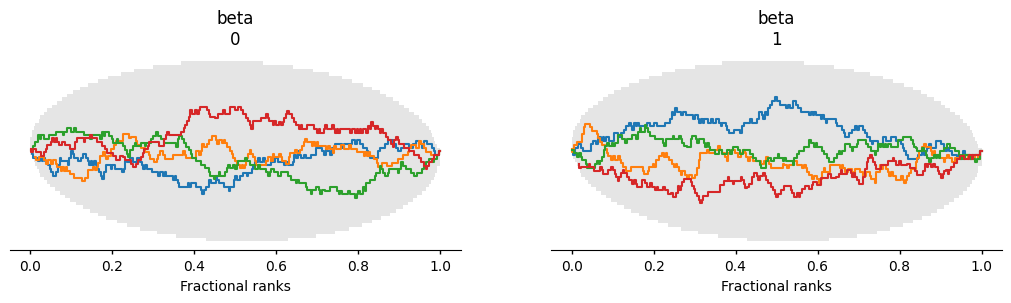

In [6]:
az.plot_rank(posterior.annotations["arviz"])
plt.show()

Each chain's line stays inside the band for both coefficients, which agrees with the R-hat values near 1.
A chain stuck in one region would hold too many low or high ranks, and its line would leave the band.
[Tutorial 2](../tutorials/02_fitting.ipynb) reads these diagnostics for a population model, and [tutorial 3](../tutorials/03_revising.ipynb) shows them for an algorithm that fails.

## Posterior predictive checks

A posterior predictive check simulates replicated data from the fitted model and compares them with the observed data through test statistics.
`predictive_check` takes the likelihood, a distribution over the likelihood's given values, the statistics, and the observed data.
With the posterior as that distribution, the check is a posterior predictive check, and with the prior it is a prior predictive check.

To show a check that fails, we also fit a second model whose rate has an intercept and no slope.
The statistic `trend` is the mean count of the upper half of `x` minus the mean count of the lower half, and `largest_count` is the largest count.

In [7]:
intercept_prior = Normal("beta", jnp.zeros(1), jnp.full(1, 2.0))
intercept_likelihood = glm_likelihood("y", PoissonFamily(), X=jnp.ones((20, 1)))
intercept_model = (intercept_likelihood * intercept_prior).with_label("intercept_only")
with workflow_run(seed=2):
    intercept_posterior = condition_on.with_options(method_options=short_chains)(
        intercept_model, {"y": y}
    )


def trend(y: jax.Array) -> jax.Array:
    return jnp.mean(y[10:]) - jnp.mean(y[:10])


def largest_count(y: jax.Array) -> jax.Array:
    return jnp.max(y)


checks = {}
with workflow_run(seed=3):
    checks["with_slope"] = predictive_check(likelihood, posterior, [trend, largest_count], {"y": y})
    checks["intercept_only"] = predictive_check(
        intercept_likelihood, intercept_posterior, [trend, largest_count], {"y": y}
    )

pd.DataFrame(
    {
        name: {
            "observed trend": float(check["trend/observed_statistic"]),
            "p-value of trend": float(check["trend/p_value"]),
            "observed largest count": float(check["largest_count/observed_statistic"]),
            "p-value of largest count": float(check["largest_count/p_value"]),
        }
        for name, check in checks.items()
    }
).T

,observed trend,p-value of trend,observed largest count,p-value of largest count
with_slope,2.9,0.464,9.0,0.656
intercept_only,2.9,0.000,9.0,0.232


A p-value is the share of replications whose statistic is at least the observed one, so a p-value near 0 or 1 signals that the model misses that feature of the data.
The intercept-only model replicates counts with no trend, so none of its 500 replications has a trend as large as the observed 2.9, and its p-value is 0.
The model with a slope reproduces both statistics.
Each check's field `replicated_statistics` is the distribution of the statistic over the 500 replications, for a histogram as in the [quickstart](../get_started/quickstart.ipynb).

`add_ppc` runs the same check and records its result on the posterior, where `posterior.diagnostics.ppc` reads it:

In [8]:
with workflow_run(seed=4):
    add_ppc(intercept_posterior, trend, {"y": y}, kernel=intercept_likelihood)
print("p-value of each statistic:", intercept_posterior.diagnostics.ppc.p_values)

p-value of each statistic: {'trend': 0.0}


## Comparing models with leave-one-out cross-validation

Leave-one-out cross-validation scores a model by how well it predicts each observation from the other observations.
`add_loo` estimates the expected log predictive density (ELPD) of the left-out observations by Pareto-smoothed importance sampling (PSIS), which reuses the posterior's draws instead of refitting the model once per observation.
Given the model and the observed data, it computes the log likelihood of each observation at each draw, so the likelihood must score each observation, as `glm_likelihood` does.

In [9]:
for name, fit, joint in [
    ("with_slope", posterior, model),
    ("intercept_only", intercept_posterior, intercept_model),
]:
    add_loo(fit, model=joint, data={"y": y})
    loo = fit.diagnostics.loo
    print(
        f"{name}: ELPD {loo.elpd_loo:.1f} (standard error {loo.se:.1f}), "
        f"effective number of parameters {loo.p_loo:.1f}, largest Pareto k {loo.pareto_k_max:.2f}"
    )

with_slope: ELPD -38.8 (standard error 2.2), effective number of parameters 1.6, largest Pareto k 0.38
intercept_only: ELPD -45.4 (standard error 3.9), effective number of parameters 1.3, largest Pareto k 0.19


A larger ELPD means better predictions, so the model with a slope predicts the counts better.
The effective number of parameters is close to each model's number of coefficients.
Each largest Pareto $k$ is below about 0.7, the threshold above which the importance-sampling estimate for an observation is unreliable.

The two ELPDs share the same observations, so their difference has a smaller standard error than either ELPD.
`add_loo` also records the pointwise log likelihood in the ArviZ data, so `az.compare` ranks the models and reports the standard error of each difference (`dse`):

In [10]:
az.compare(
    {
        "with_slope": posterior.annotations["arviz"],
        "intercept_only": intercept_posterior.annotations["arviz"],
    }
)

,rank,elpd,p,elpd_diff,weight,se,dse,warning
with_slope,0,-39.0,1.6,0.0,1.0,2.2,0.0,False
intercept_only,1,-45.0,1.3,-7.0,0.0,3.9,3.7,False


The intercept-only model's ELPD is about 7 lower, which is about twice the standard error of the difference, so the comparison favors the model with a slope.

## Interval coverage of one posterior

We simulated the counts from known coefficients, so we can ask whether the posterior's central credible intervals contain them.
`interval_coverage` takes the posterior, or an array of draws with one column per parameter, and the true values, and it returns, for each level, whether each parameter's central interval contains its true value:

In [11]:
covered = interval_coverage(posterior, true_beta, levels=(0.5, 0.9))
for level, holds in covered.items():
    print(f"{level:.0%} intervals contain the intercept and the slope:", holds)

50% intervals contain the intercept and the slope: [False  True]
90% intervals contain the intercept and the slope: [ True  True]


Here the 50% interval of the intercept misses its true value, which a calibrated posterior does for half of all datasets.
One posterior gives one yes or no per parameter and level, which says little on its own.
Over many datasets simulated from the model, a calibrated posterior's 50% intervals contain the truth in about half of them and its 90% intervals in about 90%.
[Tutorial 6](../tutorials/06_simulating.ipynb) averages `interval_coverage` over 200 simulations to check an amortized posterior.
The next section automates that loop.

## Simulation-based calibration

Simulation-based calibration tests the procedure that produces a posterior, over many simulated datasets.
Each replication draws parameters $\theta^\star$ and data $y$ from the joint model, forms the posterior at $y$, and ranks $\theta^\star$ among $L$ draws from that posterior.
When the posterior is calibrated, each rank is uniform on $\{0, \ldots, L\}$.

A conjugate model makes the check fast, because its posterior has a formula.
The prior of $\mu$ is normal with mean 0 and standard deviation 2, and the five observations are normal with mean $\mu$ and standard deviation 1.
The posterior of $\mu$ is normal, with precision $1/4 + 5$ and mean $\sum_i y_i$ divided by that precision.
`conditional_distribution` builds the posterior as a kernel from the observations to $\mu$:

In [12]:
mu_prior = Normal("mu", 0.0, 2.0)


def observations_given_mu(mu: jax.Array) -> Normal:
    return Normal("y", mu * jnp.ones(5), 1.0)


observations = conditional_distribution(
    "observations", observations_given_mu, given_spec=mu_prior.event_spec.components
)
normal_model = (observations * mu_prior).with_label("normal_model")

precision = 1 / 4 + 5


def exact_posterior_given_y(y: jax.Array) -> Normal:
    return Normal("mu", jnp.sum(y) / precision, precision**-0.5)


exact_posterior = conditional_distribution(
    "exact_posterior", exact_posterior_given_y, given_spec={"y": NumericArraySpec((5,))}
)

with workflow_run(seed=1):
    exact_sbc = simulation_based_calibration(
        normal_model,
        observed="y",
        posterior=exact_posterior,
        num_simulations=200,
        num_posterior_draws=99,
    )
print("ranks: shape", exact_sbc.ranks.shape, "for the parameters", exact_sbc.param_names)
print("KS p-value of uniform ranks:", exact_sbc.ks_pvalue)
print("coverage of the 50% and 90% intervals:", exact_sbc.coverage((0.5, 0.9)))

ranks: shape (200, 1) for the parameters ('mu',)
KS p-value of uniform ranks: [0.9004324]
coverage of the 50% and 90% intervals: {0.5: array([0.46]), 0.9: array([0.89])}


`observed="y"` names the fields of a joint draw that the posterior conditions on, and the other fields are the parameters.
The posterior kernel's given slot `y` takes the observed field `y`.
`ks_pvalue` is the p-value of a Kolmogorov–Smirnov test that each parameter's ranks are uniform, and `coverage(levels)` is the share of replications whose $\theta^\star$ lies in the posterior's central interval of each level.
The exact posterior's ranks pass the test, and its intervals contain $\theta^\star$ at rates close to their levels.

A posterior that is too narrow fails both checks.
Halving the exact posterior's standard deviation gives overconfident intervals:

KS p-value of uniform ranks: [3.76274176e-07]
coverage of the 50% and 90% intervals: {0.5: array([0.255]), 0.9: array([0.57])}


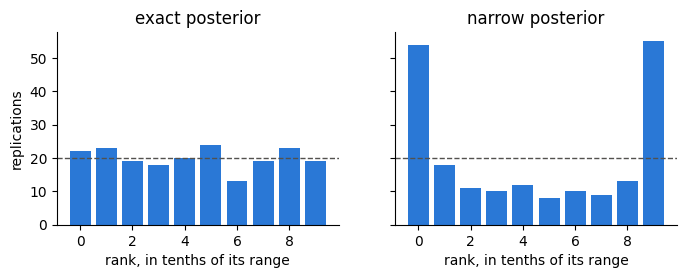

In [13]:
def narrow_posterior_given_y(y: jax.Array) -> Normal:
    return Normal("mu", jnp.sum(y) / precision, 0.5 * precision**-0.5)


narrow_posterior = conditional_distribution(
    "narrow_posterior", narrow_posterior_given_y, given_spec={"y": NumericArraySpec((5,))}
)
with workflow_run(seed=1):
    narrow_sbc = simulation_based_calibration(
        normal_model,
        observed="y",
        posterior=narrow_posterior,
        num_simulations=200,
        num_posterior_draws=99,
    )
print("KS p-value of uniform ranks:", narrow_sbc.ks_pvalue)
print("coverage of the 50% and 90% intervals:", narrow_sbc.coverage((0.5, 0.9)))

fig, axes = plt.subplots(1, 2, figsize=(8, 2.5), sharey=True)
for ax, (name, result) in zip(
    axes, [("exact posterior", exact_sbc), ("narrow posterior", narrow_sbc)]
):
    ax.bar(np.arange(10), result.rank_histogram(num_bins=10)[0], color="#2a78d6")
    ax.axhline(200 / 10, color="#52514e", linestyle="--", linewidth=1)
    ax.set_title(name)
    ax.set_xlabel("rank, in tenths of its range")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("replications")
plt.show()

`rank_histogram` bins each parameter's ranks, and the dashed line marks the count of a uniform histogram.
The exact posterior's histogram is flat up to noise.
The narrow posterior's histogram has a U shape, because its draws cluster around the posterior mean and $\theta^\star$ often falls outside all of them.
Its 90% intervals cover $\theta^\star$ in 57% of the replications.

Without `posterior=`, each replication fits the model at its simulated data with an inference method instead, so the check tests that method.
`method=` names the method and `method_options=` sets its options, as `condition_on.with_options` takes them.
Each replication runs a full fit, so the check costs `num_simulations` fits.
The run below uses 20 replications of one short chain to stay fast.
Twenty replications detect only gross miscalibration.

In [14]:
with workflow_run(seed=5):
    nuts_sbc = simulation_based_calibration(
        normal_model,
        observed="y",
        method="blackjax_nuts",
        method_options={"num_chains": 1, "num_warmup": 200, "num_results": 100},
        num_simulations=20,
        num_posterior_draws=49,
    )
print("KS p-value of uniform ranks:", nuts_sbc.ks_pvalue)
print("coverage of the 50% and 90% intervals:", nuts_sbc.coverage((0.5, 0.9)))

KS p-value of uniform ranks: [0.9187349]
coverage of the 50% and 90% intervals: {0.5: array([0.45]), 0.9: array([0.95])}


The ranks assume nearly independent posterior draws, so `num_posterior_draws` should not exceed the effective sample size of each fit's draws.
The chain length in `method_options` sets that effective sample size.
`posterior=` also takes an amortized posterior from `learn_amortized_posterior`, whose given slot `observation` takes the one observed field.
Each replication then evaluates the network with no fit, so a calibration check of an amortized posterior can afford hundreds of replications.

## See also

- [Diagnostics](../api/diagnostics.md): `add_mcmc_diagnostics`, `add_ppc`, `add_loo`, and the views that `posterior.diagnostics` returns.
- [Validation](../api/validation.md): `predictive_check`, `interval_coverage`, `simulation_based_calibration`, `SBCResult`, and the scores of a posterior against a reference posterior.
- [Conditioning and inference methods](05_conditioning_and_inference.ipynb) fits the posteriors that this chapter checks.
- [Tutorial 2](../tutorials/02_fitting.ipynb) runs MCMC diagnostics and a posterior predictive check on a population model, and [tutorial 3](../tutorials/03_revising.ipynb) revises the model after the check fails.
- [Tutorial 6](../tutorials/06_simulating.ipynb) checks the interval coverage of an amortized posterior.